In [412]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [413]:
df=pd.read_csv('naive_bayes_dataset.csv')
df

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Class
0,-0.484050,-2.419303,0.060795,2.476218,-0.411390,1.225608,1
1,0.638451,1.194533,-0.758677,1.897100,-1.758193,0.380607,0
2,-1.641253,1.344546,0.267792,-0.071650,-0.615229,-2.309030,2
3,-0.448768,-1.729425,0.580003,-1.427379,0.311702,-1.887057,1
4,-0.158617,2.003090,1.532566,-1.756997,0.737291,0.571257,2
...,...,...,...,...,...,...,...
495,-0.168093,0.274695,1.088114,-0.200984,0.424473,-1.392044,1
496,-1.349549,-0.081197,0.808223,-2.192944,0.460330,2.962177,2
497,-0.356290,1.504605,1.452589,-0.046948,1.368130,-2.777164,2
498,-1.077874,0.500820,1.854911,0.090760,0.810081,0.531670,1


In [414]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature_1  500 non-null    float64
 1   Feature_2  500 non-null    float64
 2   Feature_3  500 non-null    float64
 3   Feature_4  500 non-null    float64
 4   Feature_5  500 non-null    float64
 5   Feature_6  500 non-null    float64
 6   Class      500 non-null    int64  
dtypes: float64(6), int64(1)
memory usage: 27.5 KB


In [415]:
df.describe()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Class
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.060291,-0.305071,0.334700,0.027704,0.056905,-0.040661,0.994000
std,1.016464,1.515622,1.567857,1.648191,0.988544,1.457437,0.814427
min,-3.386814,-4.756125,-3.715971,-4.966780,-2.924925,-5.170028,0.000000
25%,-0.631264,-1.324587,-0.715418,-1.151050,-0.638717,-1.112372,0.000000
50%,0.061462,-0.216098,0.486138,0.079064,0.095285,-0.082120,1.000000
75%,0.755873,0.807073,1.403241,1.276206,0.741210,0.994071,2.000000
max,2.562528,4.392493,5.521261,5.024299,3.495878,4.058305,2.000000


<Axes: >

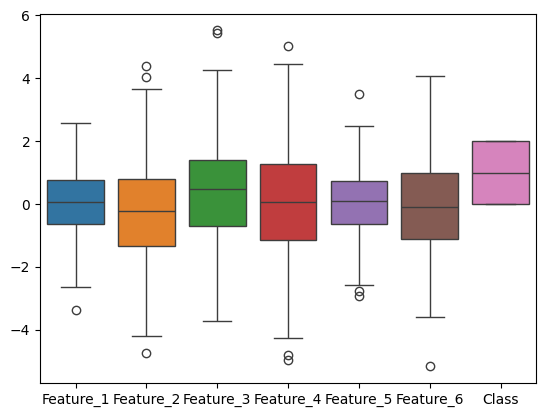

In [416]:
sns.boxplot(df)

In [417]:
x=df.drop('Class',axis=1)
y=df[['Class']].astype(int)
x


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6
0,-0.484050,-2.419303,0.060795,2.476218,-0.411390,1.225608
1,0.638451,1.194533,-0.758677,1.897100,-1.758193,0.380607
2,-1.641253,1.344546,0.267792,-0.071650,-0.615229,-2.309030
3,-0.448768,-1.729425,0.580003,-1.427379,0.311702,-1.887057
4,-0.158617,2.003090,1.532566,-1.756997,0.737291,0.571257
...,...,...,...,...,...,...
495,-0.168093,0.274695,1.088114,-0.200984,0.424473,-1.392044
496,-1.349549,-0.081197,0.808223,-2.192944,0.460330,2.962177
497,-0.356290,1.504605,1.452589,-0.046948,1.368130,-2.777164
498,-1.077874,0.500820,1.854911,0.090760,0.810081,0.531670


In [418]:
y

,Class
0,1
1,0
2,2
3,1
4,2
...,...
495,1
496,2
497,2
498,1


In [419]:
import numpy as np

for col in x.columns:
    Q1 = x[col].quantile(0.25)
    Q3 = x[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    x[col] = np.clip(x[col], lower, upper)


<Axes: >

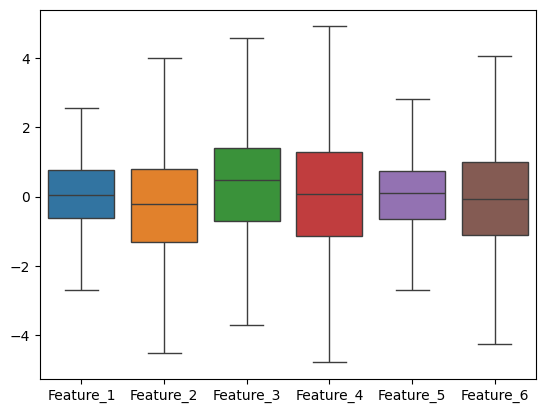

In [420]:
sns.boxplot(x)

In [421]:
y.nunique()

Class    3
dtype: int64

<Axes: >

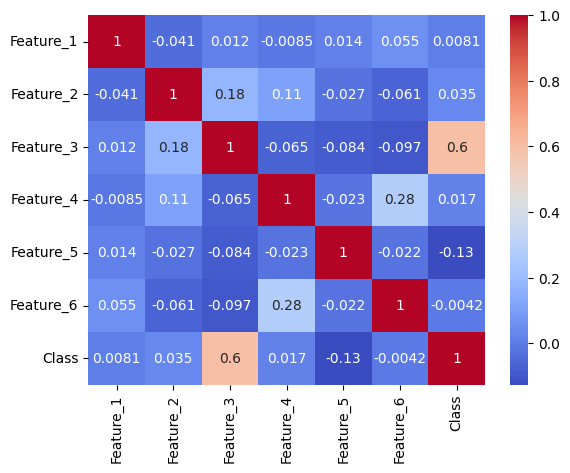

In [422]:
sns.heatmap(df.corr(),cmap='coolwarm',annot=True)

In [423]:
df.columns

Index(['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5',
       'Feature_6', 'Class'],
      dtype='object')

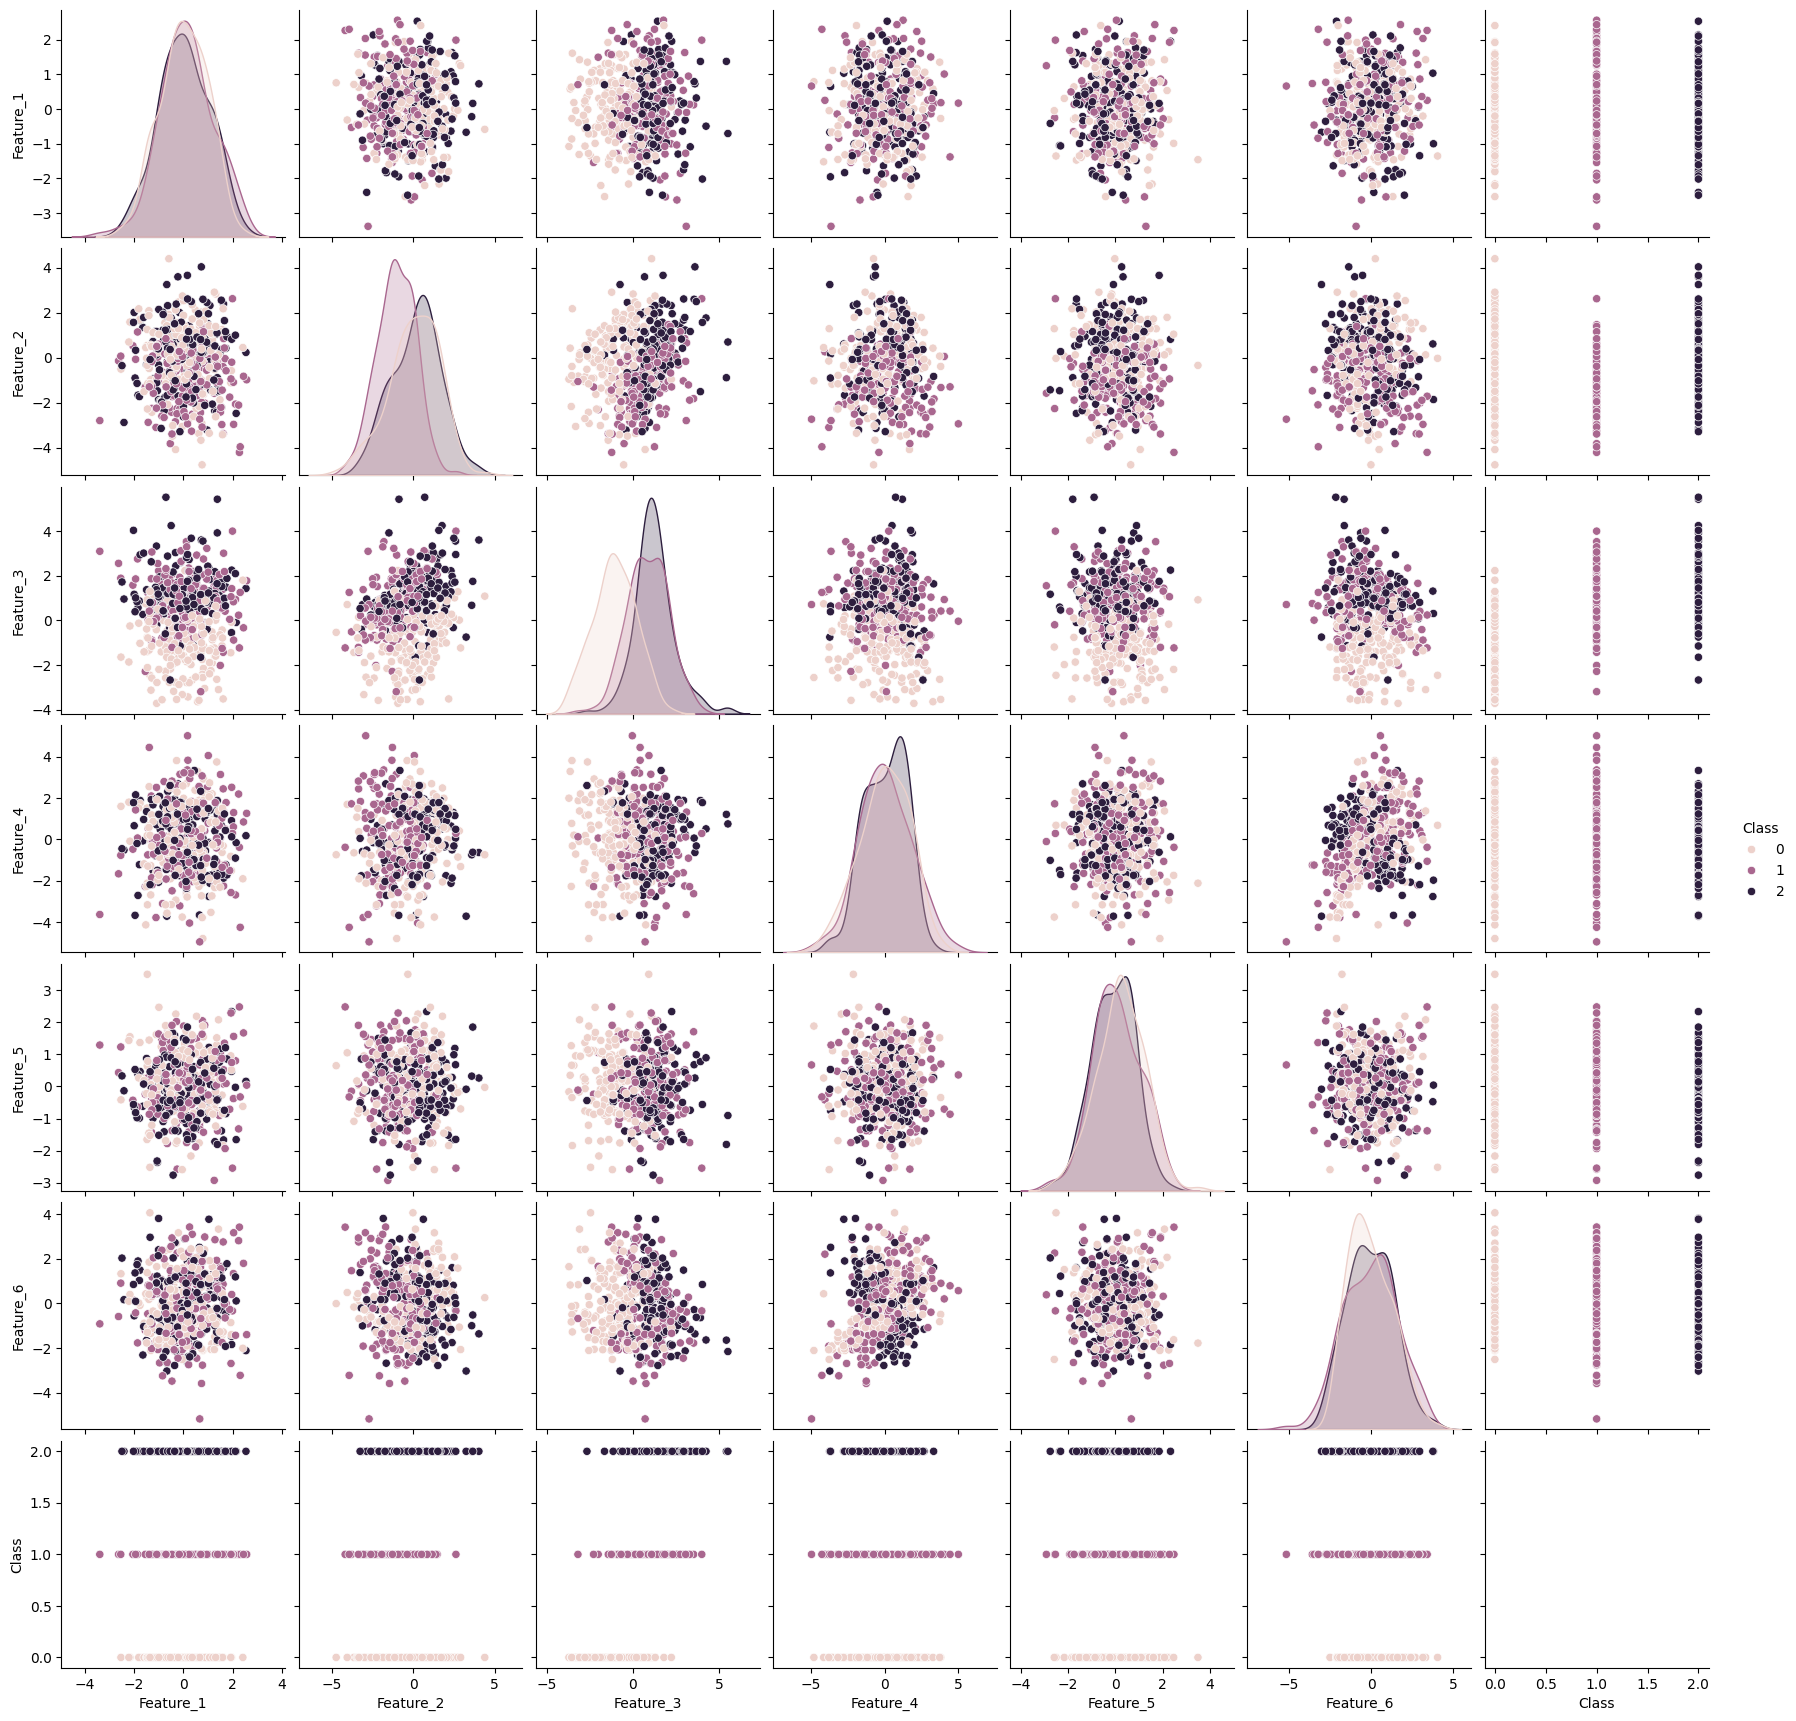

In [424]:
sns.pairplot(
    df,
    vars=['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5',
       'Feature_6', 'Class'],
    hue='Class'
)

In [425]:
x.describe()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.061641,-0.305432,0.331117,0.027867,0.056073,-0.038865
std,1.012317,1.511814,1.557065,1.646420,0.982671,1.451645
min,-2.711968,-4.522077,-3.715971,-4.791933,-2.708607,-4.272036
25%,-0.631264,-1.324587,-0.715418,-1.151050,-0.638717,-1.112372
50%,0.061462,-0.216098,0.486138,0.079064,0.095285,-0.082120
75%,0.755873,0.807073,1.403241,1.276206,0.741210,0.994071
max,2.562528,4.004563,4.581230,4.917090,2.811100,4.058305


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.,random_state=42)
x_train

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6
227,-1.065700,0.269695,0.466220,-1.701403,-2.321630,1.223018
417,0.255053,0.808254,0.440338,0.603785,0.226509,-2.394864
203,0.184942,-1.230015,0.427635,-1.026662,0.010175,-1.130227
126,0.435675,-0.394770,1.374884,1.661183,-0.817402,0.304668
329,0.025427,-0.823532,-0.580626,-0.670675,0.151619,-0.975761
...,...,...,...,...,...,...
106,-1.232321,0.720047,1.094838,1.676391,-0.996593,-0.631747
270,-2.529716,-0.507777,-1.643461,1.603025,-0.415002,1.329034
348,-1.030015,-0.808787,0.166592,-1.625974,-0.860013,-2.065278
435,0.318105,2.490143,3.684290,-0.317229,0.988681,-0.620513


In [427]:
y_train

,Class
227,2
417,2
203,0
126,1
329,0
...,...
106,2
270,0
348,1
435,2


In [428]:
x_test

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6
361,1.763557,0.922913,1.881965,-1.721426,0.856451,1.777553
73,0.249902,-1.711179,0.243492,-1.059046,-1.381995,3.421428
374,-1.935766,-0.072508,1.859475,1.428730,-0.820122,-0.422579
155,0.577026,0.422459,-3.643882,3.295533,0.349812,0.824189
104,-0.818997,0.905629,0.009504,-1.128713,0.285919,-1.628436
...,...,...,...,...,...,...
220,0.301421,-0.063935,2.095172,-0.696409,0.133151,0.523313
176,0.813074,-1.626636,-2.153350,-0.616485,0.503285,-0.565772
320,0.357838,-1.890744,-0.411209,0.190516,1.516813,3.096805
153,0.363119,-2.507090,1.866353,-2.045516,1.075393,-2.007164


In [429]:
x_test

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6
361,1.763557,0.922913,1.881965,-1.721426,0.856451,1.777553
73,0.249902,-1.711179,0.243492,-1.059046,-1.381995,3.421428
374,-1.935766,-0.072508,1.859475,1.428730,-0.820122,-0.422579
155,0.577026,0.422459,-3.643882,3.295533,0.349812,0.824189
104,-0.818997,0.905629,0.009504,-1.128713,0.285919,-1.628436
...,...,...,...,...,...,...
220,0.301421,-0.063935,2.095172,-0.696409,0.133151,0.523313
176,0.813074,-1.626636,-2.153350,-0.616485,0.503285,-0.565772
320,0.357838,-1.890744,-0.411209,0.190516,1.516813,3.096805
153,0.363119,-2.507090,1.866353,-2.045516,1.075393,-2.007164


<Axes: xlabel='Class', ylabel='count'>

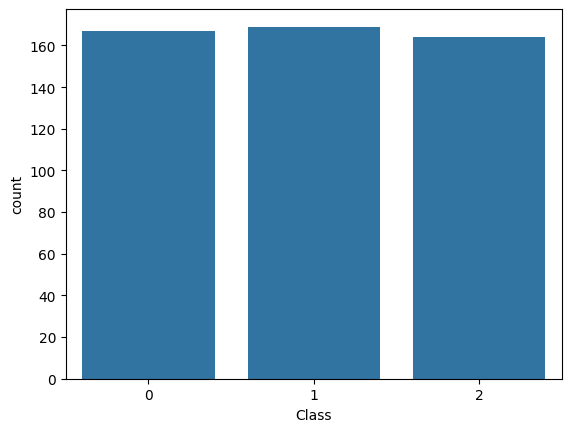

In [430]:
sns.countplot(x=y['Class'])

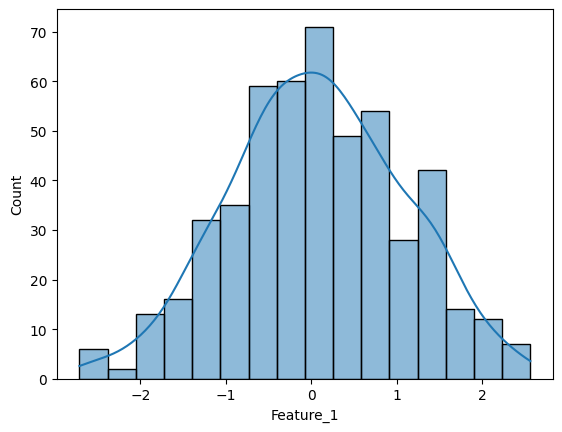

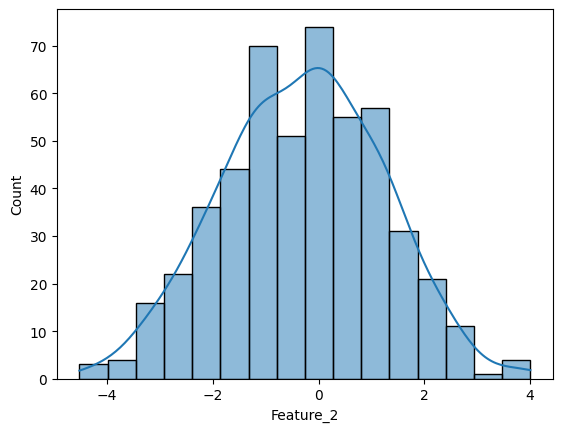

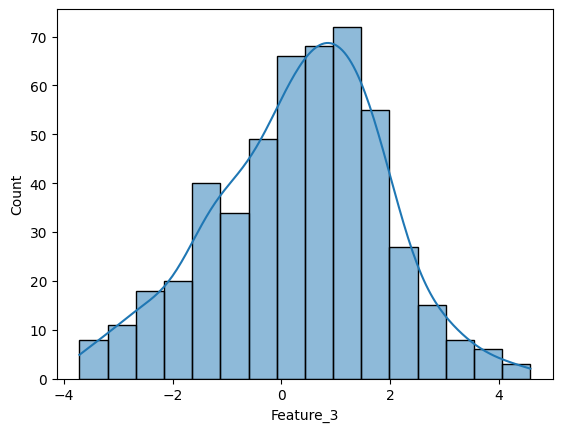

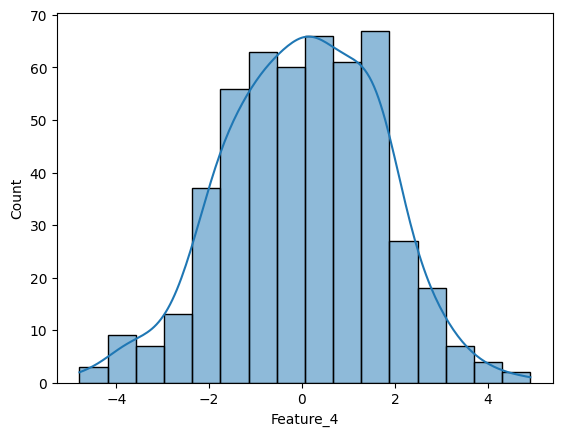

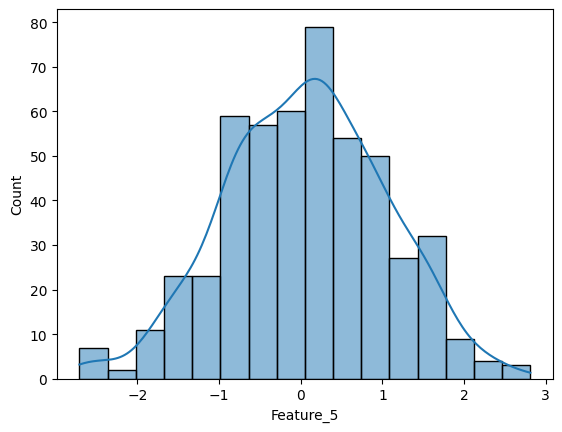

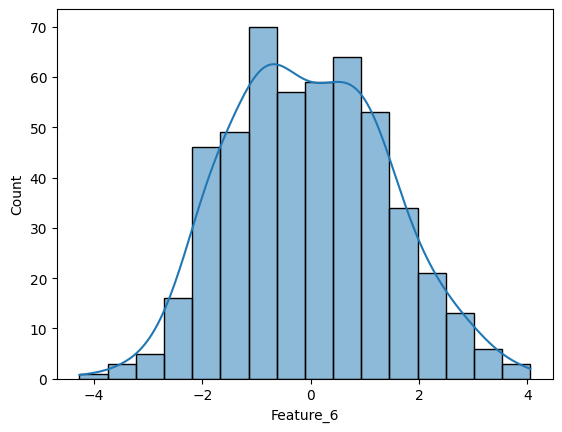

In [431]:
for i in x.columns:
    sns.histplot(x[i],kde=True)
    plt.show()

In [432]:
from sklearn.naive_bayes import GaussianNB

gnb=GaussianNB()
gnb.fit(x_train,y_train)

,priors,None
,var_smoothing,1e-09


In [433]:
ypred=gnb.predict(x_test)
ypred

array([2, 1, 2, 0, 0, 0, 0, 0, 0, 2, 0, 1, 1, 1, 0, 0, 2, 0, 2, 2, 2, 2,
       1, 2, 2, 0, 2, 2, 0, 0, 0, 2, 1, 2, 2, 0, 2, 2, 0, 1, 0, 2, 2, 1,
       1, 2, 1, 2, 2, 2, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 2, 0, 2, 2, 1, 2,
       2, 1, 0, 1, 1, 1, 1, 2, 2, 2, 0, 0, 2, 2, 1, 2, 0, 0, 0, 1, 0, 2,
       1, 1, 0, 2, 1, 0, 2, 2, 1, 2, 0, 1, 0, 1, 2, 2, 1, 0, 2, 0, 0, 2,
       1, 2, 0, 2, 2, 2, 1, 1, 2, 0, 2, 0, 1, 1, 1])

In [434]:
res=pd.DataFrame(columns=['actual','predicted'])
res['actual']=y_test
res['predicted']=ypred
res.reset_index()
res.head()

,actual,predicted
361,2,2
73,1,1
374,1,2
155,0,0
104,0,0


Accuracy: 0.672
              precision    recall  f1-score   support

           0       0.80      0.85      0.82        39
           1       0.66      0.55      0.60        42
           2       0.57      0.64      0.60        44

    accuracy                           0.67       125
   macro avg       0.68      0.68      0.67       125
weighted avg       0.67      0.67      0.67       125



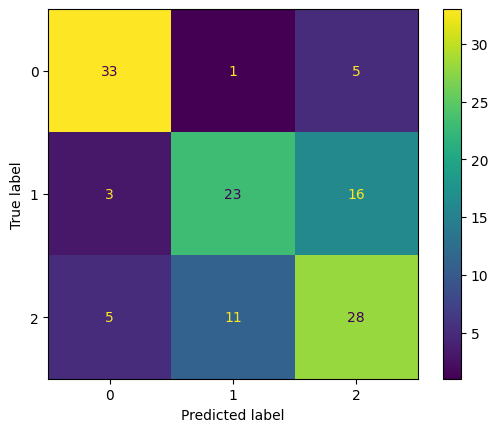

In [435]:
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay,classification_report
print("Accuracy:", accuracy_score(y_test, ypred))
print(classification_report(y_test, ypred))
ConfusionMatrixDisplay.from_estimator(gnb, x_test, y_test)
plt.show()